# 02 — Models and the walk-forward backtest

Prototype 1 ended with one fixed out-of-time split (train through 2008, test 2010-2013)
and a regularised logistic regression that beat the Texas ratio by a small margin. This
notebook tells the Prototype 2 story: a wider feature set (`features_v2`), four model
families compared on that same fixed split, and then the test that matters, a
**walk-forward backtest** with one model per year from 2008 to 2024, bootstrap
confidence intervals, calibration, lead time, and the question of what the numbers mean
in the quiet years after 2014. Everything here is read from `data/parquet/`, `models/`,
`runs/` and `reports/`; nothing is retrained.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "config" / "settings.yaml").exists() else Path.cwd().parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from bankcanary.config import load_settings
from bankcanary.evaluation.metrics_report import (
    ci_table,
    failure_dates,
    lead_time_tables,
    reliability_table,
)
from bankcanary.features import registry
from bankcanary.storage.parquet import read_table

settings = load_settings()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 100
# One fixed colour per model family, assigned by entity and never by rank.
COLORS = {
    "texas": "#2a78d6",
    "logit": "#eb6834",
    "gbdt": "#1baf7a",
    "hazard": "#eda100",
    "gbdt_mono": "#e87ba4",
}
MODELS_4Q = ["texas", "logit", "gbdt", "hazard"]
print("models_dir:", settings.models_dir)

models_dir: /Users/batuhanisik/Desktop/Projects/bank-failure-early-warning/models


## 1. What changed since Prototype 1: `features_v2`

Prototype 1 scored banks on 43 credit, capital, earnings, liquidity and concentration
ratios (`features_v1`). Prototype 2 keeps every one of them untouched and appends 40
features in five new groups: **sensitivity** to interest rates (unrealised securities
losses against Tier 1, an adjusted leverage ratio), **run risk** (uninsured deposits,
large time deposits), **trends** (one- and four-quarter changes and persistence counts of
the key ratios), **structure** (FDIC region, community-bank flag) and **macro** (state
unemployment and house prices, the yield curve and the fed funds change, joined
point-in-time at each `avail_date`). The registry is the single source of truth: every
feature has a CAMELS group, a formula, a monotone sign and the prototype it belongs to.

In [2]:
specs = registry.specs("v2")
by_group = (
    pd.DataFrame({"group": [s.camels_group for s in specs], "prototype": [s.prototype for s in specs]})
    .groupby(["group", "prototype"]).size().unstack(fill_value=0)
)
by_group.loc["total"] = by_group.sum()
print(f"{len(specs)} registry features in features_v2: "
      f"{sum(s.prototype == 'P1' for s in specs)} P1 + {sum(s.prototype == 'P2' for s in specs)} P2")
by_group

83 registry features in features_v2: 43 P1 + 40 P2


prototype,P1,P2
group,,
asset_quality,7,0
capital,5,1
concentration,9,0
earnings,4,0
liquidity,4,3
macro,0,6
management,3,0
sensitivity,0,5
structure,11,6


## 2. Five models on the fixed split

Before the walk-forward, all model families were fitted once on the Prototype 1 split
(training reports 2002Q1-2008Q4 through `fixed_split_masks`, test 2010Q1-2013Q4, 4-quarter
label) so that they can be compared with the P1 baselines on identical rows:

- `texas`: rank by the Texas ratio, no fit;
- `logit_v2`: the regularised logistic regression on all 83 v2 features;
- `gbdt` / `gbdt_mono`: LightGBM without and with monotone constraints from the registry;
- `hazard`: a discrete-time hazard (one-quarter failure event), converted to a 4-quarter
  probability with `1 - (1 - h)^4`.

The hazard's own artefact reports one-quarter metrics; its 4q row below comes from the
`converted` block of its `metrics.json`, which scores the same 118,696 test rows.

In [3]:
def load_json(*parts):
    with open(Path(settings.models_dir).joinpath(*parts)) as fh:
        return json.load(fh)

rows = []
for name in ["texas", "logit_v2", "gbdt", "gbdt_mono"]:
    m = load_json(name, "metrics.json")["test"]
    rows.append({"model": name, **{k: m[k] for k in ("pr_auc", "roc_auc", "recall_at_2pct", "recall_at_top100", "n", "n_failures")}})
h = load_json("hazard", "metrics.json")["converted"]["4q"]["hazard"]
rows.append({"model": "hazard (converted 4q)", **{k: h[k] for k in ("pr_auc", "roc_auc", "recall_at_2pct", "recall_at_top100", "n", "n_failures")}})
p1 = load_json("logit", "metrics.json")["test"]
rows.append({"model": "P1 logit (v1 features)", **{k: p1[k] for k in ("pr_auc", "roc_auc", "recall_at_2pct", "recall_at_top100", "n", "n_failures")}})
fixed = pd.DataFrame(rows).set_index("model")
fixed.round(4)

,pr_auc,roc_auc,recall_at_2pct,recall_at_top100,n,n_failures
model,,,,,,
texas,0.3726,0.9739,0.7611,0.0720,118696,833
logit_v2,0.4437,0.9823,0.7815,0.0840,118696,833
gbdt,0.4324,0.9840,0.7791,0.0732,118696,833
gbdt_mono,0.4755,0.9838,0.8019,0.0864,118696,833
hazard (converted 4q),0.3633,0.9759,0.6903,0.0792,118696,833
P1 logit (v1 features),0.3867,0.9755,0.7143,0.0804,118696,833


The tree models and the logit all clear the Texas ratio on this split, and the widened
feature set lifts the logit from a PR-AUC of 0.387 (v1) to 0.444 (v2); the converted
hazard falls just short of the Texas ratio here (0.363) and yet leads the walk-forward
below, a first hint of how much one split can mislead. But one split is
one draw: the training window ends in 2008 and the test window is the heart of the
crisis, so these numbers say how well a 2008-vintage model would have ranked 2010-2013.
The walk-forward asks the harder question.

## 3. The walk-forward backtest, 2008-2024

For every test year Y a fresh model is trained on every earlier bank-quarter whose
outcome window closed before Y's first prediction date (`training_mask`, rule 6.2), the
hyper-parameters are re-selected on a validation slice inside that training period (rule
6.7), and the label-complete reports dated in Y are scored. `walkforward_scores` holds
one row per bank-quarter, model and test year; the tables below recompute the metrics
from those rows, with **cluster-bootstrap** intervals that resample banks (200 draws,
seed 20080101) so that the consecutive quarters of one bank move together.

In [4]:
wf = read_table("walkforward_scores", settings)
wf4 = wf[wf["horizon"] == 4]
ci = {m: ci_table(wf4[wf4["model"] == m]) for m in MODELS_4Q}
pooled = pd.DataFrame(
    {m: ci[m].set_index("year").loc["pooled"] for m in MODELS_4Q}
).T[["n", "n_failures", "pr_auc", "pr_auc_low", "pr_auc_high", "recall_at_2pct", "recall_at_2pct_low", "recall_at_2pct_high", "roc_auc"]]
pooled.astype(float).round(4)

evaluate: no failures among 19942 rows; metrics are NaN


evaluate: no failures among 19942 rows; metrics are NaN


evaluate: no failures among 19942 rows; metrics are NaN


evaluate: no failures among 19942 rows; metrics are NaN


,n,n_failures,pr_auc,pr_auc_low,pr_auc_high,recall_at_2pct,recall_at_2pct_low,recall_at_2pct_high,roc_auc
texas,426019.0,2103.0,0.2606,0.2255,0.2980,0.7437,0.7158,0.7707,0.9599
logit,426019.0,2103.0,0.3066,0.2756,0.3350,0.6843,0.6571,0.7127,0.9613
gbdt,426019.0,2103.0,0.2813,0.2505,0.3112,0.6434,0.6090,0.6688,0.8206
hazard,426019.0,2103.0,0.3261,0.2934,0.3567,0.7042,0.6787,0.7287,0.9577


In [5]:
per_year = pd.concat({m: ci[m].set_index("year") for m in MODELS_4Q}, axis=1)
table = pd.DataFrame({"n": ci["logit"].set_index("year")["n"], "failures": ci["logit"].set_index("year")["n_failures"]})
for m in MODELS_4Q:
    table[f"pr_auc {m}"] = per_year[(m, "pr_auc")].round(3)
for m in MODELS_4Q:
    table[f"recall@2% {m}"] = per_year[(m, "recall_at_2pct")].round(3)
table["low confidence"] = np.where(per_year[("logit", "low_confidence")].astype(bool), "yes", "")
table

,n,failures,pr_auc texas,pr_auc logit,pr_auc gbdt,pr_auc hazard,recall@2% texas,recall@2% logit,recall@2% gbdt,recall@2% hazard,low confidence
year,,,,,,,,,,,
2008,33972,429,0.351,0.302,0.110,0.322,0.541,0.492,0.273,0.520,
2009,32811,679,0.571,0.417,0.386,0.456,0.557,0.424,0.420,0.443,
2010,31431,408,0.484,0.459,0.438,0.490,0.647,0.618,0.632,0.647,
2011,30165,231,0.417,0.511,0.542,0.551,0.775,0.823,0.857,0.870,
2012,29130,121,0.357,0.485,0.463,0.534,0.909,0.942,0.959,0.967,
2013,27970,73,0.166,0.368,0.407,0.419,0.712,0.849,0.877,0.877,
2014,26792,37,0.122,0.436,0.515,0.424,0.865,0.973,0.973,0.973,
2015,25517,24,0.115,0.267,0.309,0.331,0.917,1.000,1.000,1.000,
2016,24351,28,0.104,0.534,0.409,0.490,0.821,0.964,0.929,0.857,


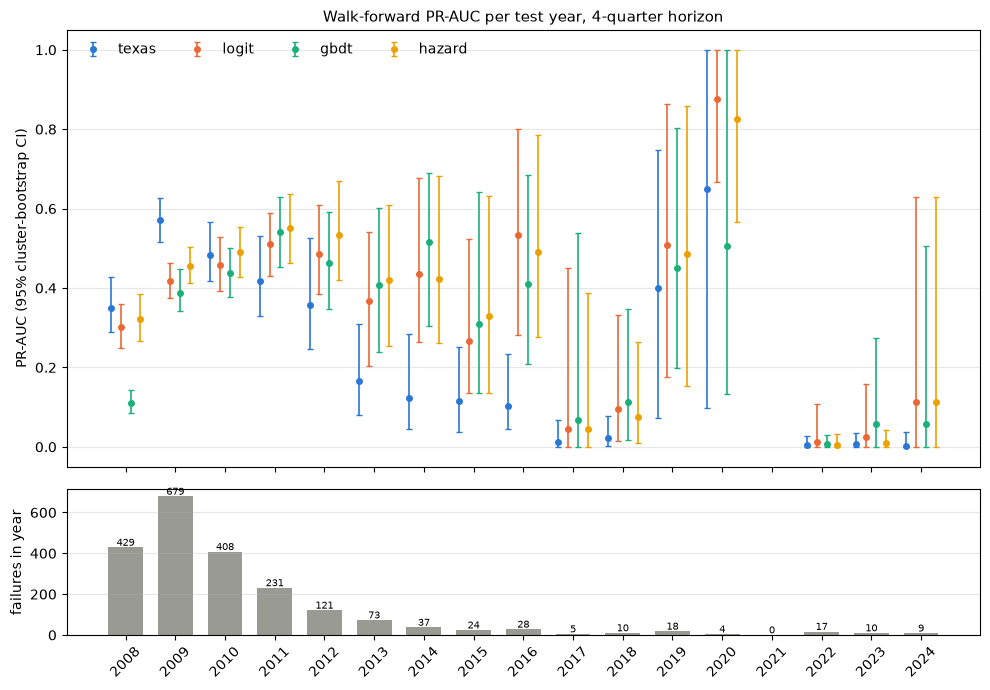

In [6]:
years = [int(y) for y in ci["logit"]["year"] if y != "pooled"]
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
offsets = np.linspace(-0.3, 0.3, len(MODELS_4Q))
for off, m in zip(offsets, MODELS_4Q):
    t = ci[m][ci[m]["year"] != "pooled"]
    x = np.array(years, dtype=float) + off
    err = np.vstack([t["pr_auc"] - t["pr_auc_low"], t["pr_auc_high"] - t["pr_auc"]])
    ax.errorbar(x, t["pr_auc"], yerr=err, fmt="o", ms=4, lw=1.2, capsize=2, color=COLORS[m], label=m)
ax.set_ylabel("PR-AUC (95% cluster-bootstrap CI)")
ax.set_title("Walk-forward PR-AUC per test year, 4-quarter horizon", fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.legend(ncol=4, frameon=False)
fails = ci["logit"][ci["logit"]["year"] != "pooled"]["n_failures"].to_numpy()
ax2.bar(years, fails, color="#9a9a94", width=0.7)
for x, f in zip(years, fails):
    ax2.text(x, f + 8, str(int(f)), ha="center", fontsize=7)
ax2.set_ylabel("failures in year")
ax2.set_xticks(years)
ax2.set_xticklabels(years, rotation=45)
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()

Read the chart with the failure counts underneath it. Through 2016 every model has enough
failures for the intervals to mean something, and in 2011-2014 all three fitted models
rank the failures well (PR-AUC around 0.4-0.55, recall@2% above 0.8). In 2008, the first
test year, the training data hold only the pre-crisis failures and the booster in
particular has almost nothing to learn from (PR-AUC 0.11 against 0.30-0.35 for the
logit, the hazard and the Texas ratio). From 2017 on the bars shrink to single digits
and the intervals span most of the unit interval; section 7 comes back to that.

## 4. Reliability: raw scores against the isotonic calibration

Ranking is one thing, probability another. For each test year an isotonic map was fitted
on the last complete label year inside the training window, using an *inner* model
trained on the years before that slice, and then applied to the full-window model's
scores (`score_calibrated`). The curves below bin the pooled test rows by raw-score
decile and compare the mean raw score, the mean calibrated score and the observed
failure rate in each bin.

,brier raw,brier calibrated,mean raw,mean calibrated,failure rate
model,,,,,
logit,0.0041,0.0189,0.0025,0.0293,0.0049
gbdt,0.0043,0.0043,0.0020,0.0078,0.0049
hazard,0.0041,0.0545,0.0021,0.0659,0.0049


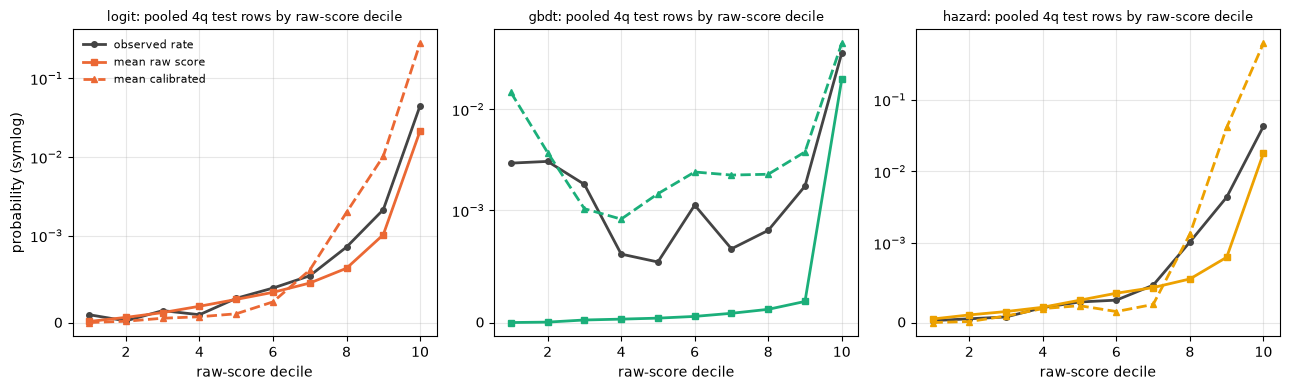

In [7]:
PROB_MODELS = ["logit", "gbdt", "hazard"]
rel = {m: reliability_table(wf4[wf4["model"] == m]) for m in PROB_MODELS}
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, m in zip(axes, PROB_MODELS):
    r = rel[m]
    ax.plot(r["decile"], r["observed_rate"], color="#444", lw=2, marker="o", ms=4, label="observed rate")
    ax.plot(r["decile"], r["mean_raw"], color=COLORS[m], lw=2, marker="s", ms=4, label="mean raw score")
    ax.plot(r["decile"], r["mean_calibrated"], color=COLORS[m], lw=2, ls="--", marker="^", ms=4, label="mean calibrated")
    ax.set_yscale("symlog", linthresh=1e-3)
    ax.set_title(f"{m}: pooled 4q test rows by raw-score decile", fontsize=9)
    ax.set_xlabel("raw-score decile")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("probability (symlog)")
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout()
brier_rows = []
for m in PROB_MODELS:
    s = wf4[wf4["model"] == m]
    y = s["y"].to_numpy(float)
    brier_rows.append({"model": m, "brier raw": np.mean((s["score"].to_numpy(float) - y) ** 2),
                       "brier calibrated": np.mean((s["score_calibrated"].to_numpy(float) - y) ** 2),
                       "mean raw": s["score"].mean(), "mean calibrated": s["score_calibrated"].mean(),
                       "failure rate": y.mean()})
pd.DataFrame(brier_rows).set_index("model").round(4)

The raw scores of all three models already sit close to the observed rate in the top
deciles, and the calibrated curve is better only for the booster (Brier 0.0043 either
way). For the logit and the hazard the calibrated scores overshoot: the map is learned
on the inner model's scale and applied to a model that has seen one more year, and where
the two scales differ (most of all in 2009-2010, when the crisis year enters the window)
the calibrated probabilities inherit the inner model's plateaus. The raw outputs remain
the better probabilities; `score_calibrated` is kept because the contract asks for it and
the mismatch is documented decile by decile in `reports/walkforward.md`.

## 5. Lead time: how many quarters ahead was a failure flagged?

For every bank that failed, the number of calendar quarters between the first report at
which it entered the top 2 percent of that quarter's ranking and its failure. The
2009-2012 cohort is the headline: 2008 failures can only be flagged inside 2008, and
failures after 2024 are scored only through 2024, so both ends are shortened by
construction.

In [8]:
fail_dates = failure_dates(settings)
lead, lead_summary = {}, []
for m in MODELS_4Q:
    lead[m], summ = lead_time_tables(wf4[wf4["model"] == m], fail_dates)
    lead_summary.append({"model": m, **{k: summ["crisis"][k] for k in ("n_failed", "n_flagged", "share_flagged", "median_lead_time_quarters", "share_flagged_ahead")}})
pd.DataFrame(lead_summary).set_index("model").round(3)

,n_failed,n_flagged,share_flagged,median_lead_time_quarters,share_flagged_ahead
model,,,,,
texas,440,372,0.845,4.0,0.825
logit,440,395,0.898,5.0,0.877
gbdt,440,364,0.827,4.5,0.816
hazard,440,398,0.905,5.0,0.884


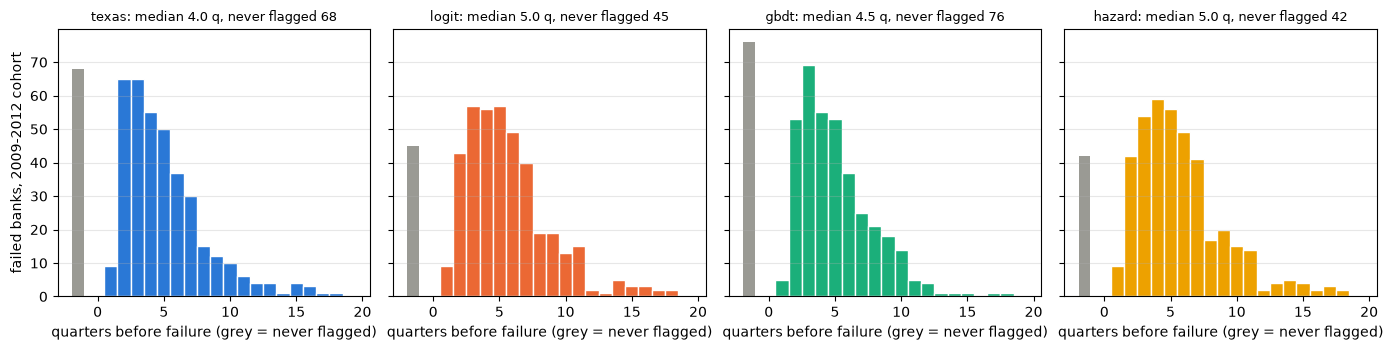

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharey=True)
bins = np.arange(-0.5, 20.5, 1)
for ax, m in zip(axes, MODELS_4Q):
    d = lead[m]
    yrs = pd.to_datetime(d["fail_date"]).dt.year
    lt = d.loc[(yrs >= 2009) & (yrs <= 2012), "lead_time_quarters"].astype(float)
    ax.hist(lt.dropna().clip(upper=20), bins=bins, color=COLORS[m], edgecolor="white")
    ax.bar([-1.5], [lt.isna().sum()], color="#9a9a94", width=0.9)
    ax.set_title(f"{m}: median {lt.median():.1f} q, never flagged {int(lt.isna().sum())}", fontsize=9)
    ax.set_xlabel("quarters before failure (grey = never flagged)")
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("failed banks, 2009-2012 cohort")
plt.tight_layout()

## 6. Monotone-constrained against unconstrained boosting (Decision Point 2)

The registry gives every feature a sign: risk-increasing (+1), risk-decreasing (-1) or
unconstrained (0). `gbdt_mono` forces the booster to respect those signs, which makes
every partial dependence explainable to a supervisor at the cost of some flexibility.
Both variants were trained on the fixed split with the same hyper-parameters; the
inner-validation PR-AUC (reports 2007Q1-2008Q4, inside the training period) is the
number rule 6.7 allows for selection, and the test columns are what the choice would
have delivered. The current setting is `settings.models.gbdt.monotone = False`, the
config with the higher inner-validation score; the owner decides with both rows in view.

In [10]:
rows = []
for name in ["gbdt", "gbdt_mono"]:
    m = load_json(name, "metrics.json")
    t = m["test"]
    rows.append({"model": name, "inner_pr_auc": m.get("inner_pr_auc", np.nan), "test pr_auc": t["pr_auc"],
                 "test recall@2%": t["recall_at_2pct"], "test roc_auc": t["roc_auc"],
                 **{f"pr_auc {y['year']}": y["pr_auc"] for y in m["by_year"]}})
mono = pd.DataFrame(rows).set_index("model")
inner = dict(getattr(settings.models.gbdt, "inner_pr_auc", {}) or {})
for k, v in inner.items():
    if k in mono.index:
        mono.loc[k, "inner_pr_auc"] = float(v)
print("settings.models.gbdt.monotone =", settings.models.gbdt.monotone)
mono.round(4)

settings.models.gbdt.monotone = False


,inner_pr_auc,test pr_auc,test recall@2%,test roc_auc,pr_auc 2010,pr_auc 2011,pr_auc 2012,pr_auc 2013,pr_auc pooled
model,,,,,,,,,
gbdt,0.2299,0.4324,0.7791,0.9840,0.4934,0.4405,0.3073,0.2858,0.4324
gbdt_mono,0.1968,0.4755,0.8019,0.9838,0.5313,0.4859,0.3952,0.2760,0.4755


Stated neutrally: on the fixed split the constrained booster scores lower on the
inner-validation slice and higher on the 2010-2013 test rows, in three of the four test
years. The inner slice is the only evidence a rule-6.7 selection may use; the test
columns are what a reviewer would see afterwards. Neither ordering is a large gap
against the year-to-year variation shown in section 3, and the walk-forward runs the
setting in `settings.yaml`, so the choice is a policy call (explainability and
guaranteed direction of effect against a free fit) rather than a statistical one.

## 7. An honest paragraph on the years after 2014

The walk-forward test rows of 2015-2024 hold 125 positive labels (bank-quarters that
failed within four quarters) in ten years, against 1,439 in 2009-2012 alone, and two of
those years (2017 and 2021) hold five or fewer. A PR-AUC on
nine failures among 18,000 banks is a statement about nine banks: the 2024 logit reads
0.11 with a bootstrap interval of [0.00, 0.63], and 2021 has no failure at all, so its
ranking metrics are undefined. The pooled rows are dominated by the crisis cohort (1,868
of the 2,103 positive rows fall in 2008-2012), so a pooled PR-AUC says how the models rank a
crisis and almost nothing about a quiet decade. Two honest readings follow. First, the
models keep working when they are given failures to find: in 2019, with 18 failures,
every fitted model has PR-AUC above 0.45 and recall@2% of 0.94. Second, the 2022-2024
failures (the rate-driven and crypto-adjacent closures) are ranked poorly by every
model, Texas ratio included, which is exactly the gap the sensitivity and run-risk
features were meant to close and is the subject of notebook 03. The table below is the
post-2014 slice of section 3 with its intervals, so the width of the uncertainty is
visible rather than hidden in a pooled average.

In [11]:
late = table.loc[[str(y) for y in years if y >= 2015]].copy()
for m in MODELS_4Q:
    t = ci[m].set_index("year")
    late[f"CI {m}"] = [f"[{lo:.2f}, {hi:.2f}]" if pd.notna(lo) else "n/a"
                       for lo, hi in zip(t.loc[late.index, "pr_auc_low"], t.loc[late.index, "pr_auc_high"])]
print(f"failures 2015-2024: {int(late['failures'].sum())}; 2009-2012: {int(table.loc[['2009', '2010', '2011', '2012'], 'failures'].sum())}")
late[["failures"] + [f"pr_auc {m}" for m in MODELS_4Q] + [f"CI {m}" for m in MODELS_4Q] + ["low confidence"]]

failures 2015-2024: 125; 2009-2012: 1439


,failures,pr_auc texas,pr_auc logit,pr_auc gbdt,pr_auc hazard,CI texas,CI logit,CI gbdt,CI hazard,low confidence
year,,,,,,,,,,
2015,24,0.115,0.267,0.309,0.331,"[0.04, 0.25]","[0.13, 0.52]","[0.14, 0.64]","[0.14, 0.63]",
2016,28,0.104,0.534,0.409,0.490,"[0.04, 0.23]","[0.28, 0.80]","[0.21, 0.69]","[0.28, 0.79]",
2017,5,0.011,0.045,0.066,0.045,"[0.00, 0.07]","[0.00, 0.45]","[0.00, 0.54]","[0.00, 0.39]",yes
2018,10,0.022,0.096,0.113,0.075,"[0.00, 0.08]","[0.01, 0.33]","[0.02, 0.35]","[0.01, 0.26]",
2019,18,0.399,0.508,0.451,0.485,"[0.07, 0.75]","[0.18, 0.86]","[0.20, 0.80]","[0.15, 0.86]",
2020,4,0.651,0.875,0.505,0.827,"[0.10, 1.00]","[0.67, 1.00]","[0.13, 1.00]","[0.57, 1.00]",yes
2021,0,NaN,NaN,NaN,NaN,n/a,n/a,n/a,n/a,yes
2022,17,0.004,0.012,0.007,0.004,"[0.00, 0.03]","[0.00, 0.11]","[0.00, 0.03]","[0.00, 0.03]",
2023,10,0.007,0.025,0.059,0.010,"[0.00, 0.04]","[0.00, 0.16]","[0.00, 0.27]","[0.00, 0.04]",


## 8. The 8-quarter horizon

The same walk-forward was run at 8 quarters for the logit and the booster (test years
2008-2023, since the 2024 windows are not yet complete). Longer horizons are harder for
every model, and the booster suffers most: its 8q pooled PR-AUC is 0.12 against 0.28 for
the logit, largely because its 2008-2010 fits, trained on almost no two-year failure
windows, rank the crisis cohort poorly.

In [12]:
wf8 = wf[wf["horizon"] == 8]
ci8 = {m: ci_table(wf8[wf8["model"] == m]) for m in ["logit", "gbdt"]}
pooled8 = pd.DataFrame({m: ci8[m].set_index("year").loc["pooled"] for m in ci8}).T
pooled8[["n", "n_failures", "pr_auc", "pr_auc_low", "pr_auc_high", "recall_at_2pct", "recall_at_2pct_low", "recall_at_2pct_high"]].astype(float).round(4)

,n,n_failures,pr_auc,pr_auc_low,pr_auc_high,recall_at_2pct,recall_at_2pct_low,recall_at_2pct_high
logit,407621.0,3768.0,0.2835,0.2519,0.3143,0.5488,0.5218,0.5768
gbdt,407621.0,3768.0,0.1169,0.0939,0.1379,0.2710,0.2431,0.3019


## 9. Where this leaves Prototype 2

- The walk-forward is the number to quote: pooled 4q PR-AUC of 0.33 (hazard), 0.31
  (logit) and 0.28 (booster) with overlapping intervals, against 0.26 for the Texas ratio;
  recall@2% between 0.64 and 0.74. The fixed-split figures are higher because 2010-2013 is
  the easiest period to rank.
- The flagged failures are flagged early: median lead of 4.5-5 quarters, 82-88 percent of
  the 2009-2012 failures at least two quarters ahead.
- Calibration is only trustworthy for the booster; the raw scores are the better
  probabilities elsewhere, and the reason is documented rather than patched.
- Post-2014 metrics are noise-dominated; the model's value in a quiet decade is what it
  says about individual banks, which notebooks 03 (SVB, 2023) and 04 (false positives)
  examine one bank at a time.